**ETUDE DE CAS : La compréhension de l’attrition au sein d’une société fictive.**

**Background**

L’attrition est un phénomène observé important au sein des entreprises, et il essentiels pour les Ressources Humaines (RH) de le comprendre. 

Ce phénomène peut se définir comme “le processus naturel de réduction progressive des effectifs d’une entreprise lorsque des employés quittent leurs postes”. Ainsi, les départs concernés par l’attrition peuvent être : 

* Démissions volontaires

* Départs à la retraite

* Fin de contrat non renouvelée 

* Décès

* Licenciements (dans certains contextes). 

Ce phénomène est important à comprendre et anticiper afin d’éviter les instabilités de personnels et les pertes de productivités associées. 

**Objectif**

L’analyse de cette base de données a pour objectif de permettre aux RH de comprendre les causes de l’attrition au sein de l’entreprise afin de construire une stratégie efficace afin de l’anticiper ou l’empêcher. 

Pour atteindre notre objectif, nous tenterons de répondre à la question suivante : 

“*Au regard du phénomène d’attrition, pourquoi les salariés quittent-ils leurs postes au sein de cette entreprise ?*” 

Au départ de cette analyse, nous partons du postulat que l’attrition est potentiellement impactée par des variables modifiables. 

**Dataset**

Nous analyserons des données provenant de IBM, en utilisant Python.

In [1]:
#Importation des packages essentiels à notre analyse : 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from fx import (
    distribution,
    segmentation_age,
    segmentation_yac,
    segmentation_yar,
    segmentation_promo,
    segmentation_ywcm,   
    attrition_int,
    an_corr,
    plot_bar,
    plot_hist,
    correlation,
    plot_analyse,
    plot_details,
    ) #importation des fonctions natives à cette analyse.

Mise en place de l'environnement de l'analyse : 

In [2]:
df = pd.read_csv("dataset/HR-Employee-Attrition.csv") #création de notre variable dataframe (df)

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


Nettoyage des données et compréhension de notre DataFrame

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

In [4]:
df.isnull().sum() #lecture des variables null par somme

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

Nos données ne comportent pas de valeurs "null", traduisant une bonne acquisition en amont.


De ce fait, nous n'avons pas besoin de réaliser du nettoyage plus approfondi.  

In [5]:
df.describe() #compréhension globale du dataframe afin de tracker les mauvaises entrées

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


Absence de données minimales ou maximales mal encodées.

Pour conclure cette phase de nettoyage, nos données ne comportent pas d'erreurs ou de problème nécessitant la mise en place d'un processus de nettoyage. 

Ainsi, nous pouvons passer à la deuxième étape de notre analyse, l'Exploratory Data Analysis (EDA) : 

In [6]:
#suppression des colonnes ne permettant pas de répondre à notre question initiale : 

usefull_cols = [
    'Age',
    'Attrition',
    'DailyRate',
    'Department',
    'DistanceFromHome',
    'Education',
    'EnvironmentSatisfaction',
    'HourlyRate',
    'JobInvolvement',
    'JobSatisfaction',
    'MonthlyIncome',
    'OverTime',
    'YearsAtCompany',
    'YearsInCurrentRole',
    'YearsSinceLastPromotion',
    'YearsWithCurrManager',
] #liste contenant l'ensemble des données utiles à notre analyse.

for cols in df.columns : #boucle for supprimer chacune des colonnes inutiles du dataframe.
    if cols not in usefull_cols :
        df = df.drop(cols, axis = 1)

In [7]:
df.head() #verification du fonctionnement de la boucle. 

,Age,Attrition,DailyRate,Department,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobSatisfaction,MonthlyIncome,OverTime,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,1102,Sales,1,2,2,94,3,4,5993,Yes,6,4,0,5
1,49,No,279,Research & Development,8,1,3,61,2,2,5130,No,10,7,1,7
2,37,Yes,1373,Research & Development,2,2,4,92,2,3,2090,Yes,0,0,0,0
3,33,No,1392,Research & Development,3,4,4,56,3,3,2909,Yes,8,7,3,0
4,27,No,591,Research & Development,2,1,1,40,3,2,3468,No,2,2,2,2


In [8]:
df.info() #analyse du dtype de notre dataframe.

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   Age                      1470 non-null   int64
 1   Attrition                1470 non-null   str  
 2   DailyRate                1470 non-null   int64
 3   Department               1470 non-null   str  
 4   DistanceFromHome         1470 non-null   int64
 5   Education                1470 non-null   int64
 6   EnvironmentSatisfaction  1470 non-null   int64
 7   HourlyRate               1470 non-null   int64
 8   JobInvolvement           1470 non-null   int64
 9   JobSatisfaction          1470 non-null   int64
 10  MonthlyIncome            1470 non-null   int64
 11  OverTime                 1470 non-null   str  
 12  YearsAtCompany           1470 non-null   int64
 13  YearsInCurrentRole       1470 non-null   int64
 14  YearsSinceLastPromotion  1470 non-null   int64
 15  YearsWithCurrMa

In [9]:
#Création de la colonne 'Attrition_int' contenant la conversion en valeur numérique pour la colonne 'Attrition' :  

df['Attrition_int'] = df.apply(attrition_int, axis = 1)

In [10]:
# Analyse globales des moyennes de notre DataFrame 

for items in df : 
    try :
        mean = df[items].mean()
        print(f"La moyenne de {items} est {mean}")
    except TypeError as e: 
        pass

La moyenne de Age est 36.923809523809524
La moyenne de DailyRate est 802.4857142857143
La moyenne de DistanceFromHome est 9.19251700680272
La moyenne de Education est 2.912925170068027
La moyenne de EnvironmentSatisfaction est 2.721768707482993
La moyenne de HourlyRate est 65.89115646258503
La moyenne de JobInvolvement est 2.7299319727891156
La moyenne de JobSatisfaction est 2.7285714285714286
La moyenne de MonthlyIncome est 6502.931292517007
La moyenne de YearsAtCompany est 7.0081632653061225
La moyenne de YearsInCurrentRole est 4.229251700680272
La moyenne de YearsSinceLastPromotion est 2.1877551020408164
La moyenne de YearsWithCurrManager est 4.12312925170068
La moyenne de Attrition_int est 0.16122448979591836


Cette analyse des moyennes nous donne une vision globale de la répartition des variables de notre DataFrame

In [11]:
# Analyse globale des médianes de notre DataFrame : 

for items in df : 
    try :
        median = df[items].median()
        print(f"La médiane de {items} est {median}")
    except TypeError as e: 
        pass

La médiane de Age est 36.0
La médiane de DailyRate est 802.0
La médiane de DistanceFromHome est 7.0
La médiane de Education est 3.0
La médiane de EnvironmentSatisfaction est 3.0
La médiane de HourlyRate est 66.0
La médiane de JobInvolvement est 3.0
La médiane de JobSatisfaction est 3.0
La médiane de MonthlyIncome est 4919.0
La médiane de YearsAtCompany est 5.0
La médiane de YearsInCurrentRole est 3.0
La médiane de YearsSinceLastPromotion est 1.0
La médiane de YearsWithCurrManager est 3.0
La médiane de Attrition_int est 0.0


Cette analyse des médianes nous donne une vision globale de la répartition des variables de notre DataFrame

In [12]:
# Analyse globale de l'écart type entre nos variables : 

for items in df : 
    try :
        std = df[items].std()
        print(f"L'écart type de {items} est {std}")
    except TypeError as e: 
        pass

L'écart type de Age est 9.135373489136732
L'écart type de DailyRate est 403.50909994352816
L'écart type de DistanceFromHome est 8.106864435666074
L'écart type de Education est 1.0241649445978729
L'écart type de EnvironmentSatisfaction est 1.0930822146350005
L'écart type de HourlyRate est 20.329427593996165
L'écart type de JobInvolvement est 0.7115611429632304
L'écart type de JobSatisfaction est 1.1028461230547204
L'écart type de MonthlyIncome est 4707.956783097994
L'écart type de YearsAtCompany est 6.126525152403569
L'écart type de YearsInCurrentRole est 3.623137034670628
L'écart type de YearsSinceLastPromotion est 3.222430279137967
L'écart type de YearsWithCurrManager est 3.5681361205404376
L'écart type de Attrition_int est 0.367863031971962


Cette analyse des écarts types nous donne une vision globale de la répartition des variables de notre DataFrame

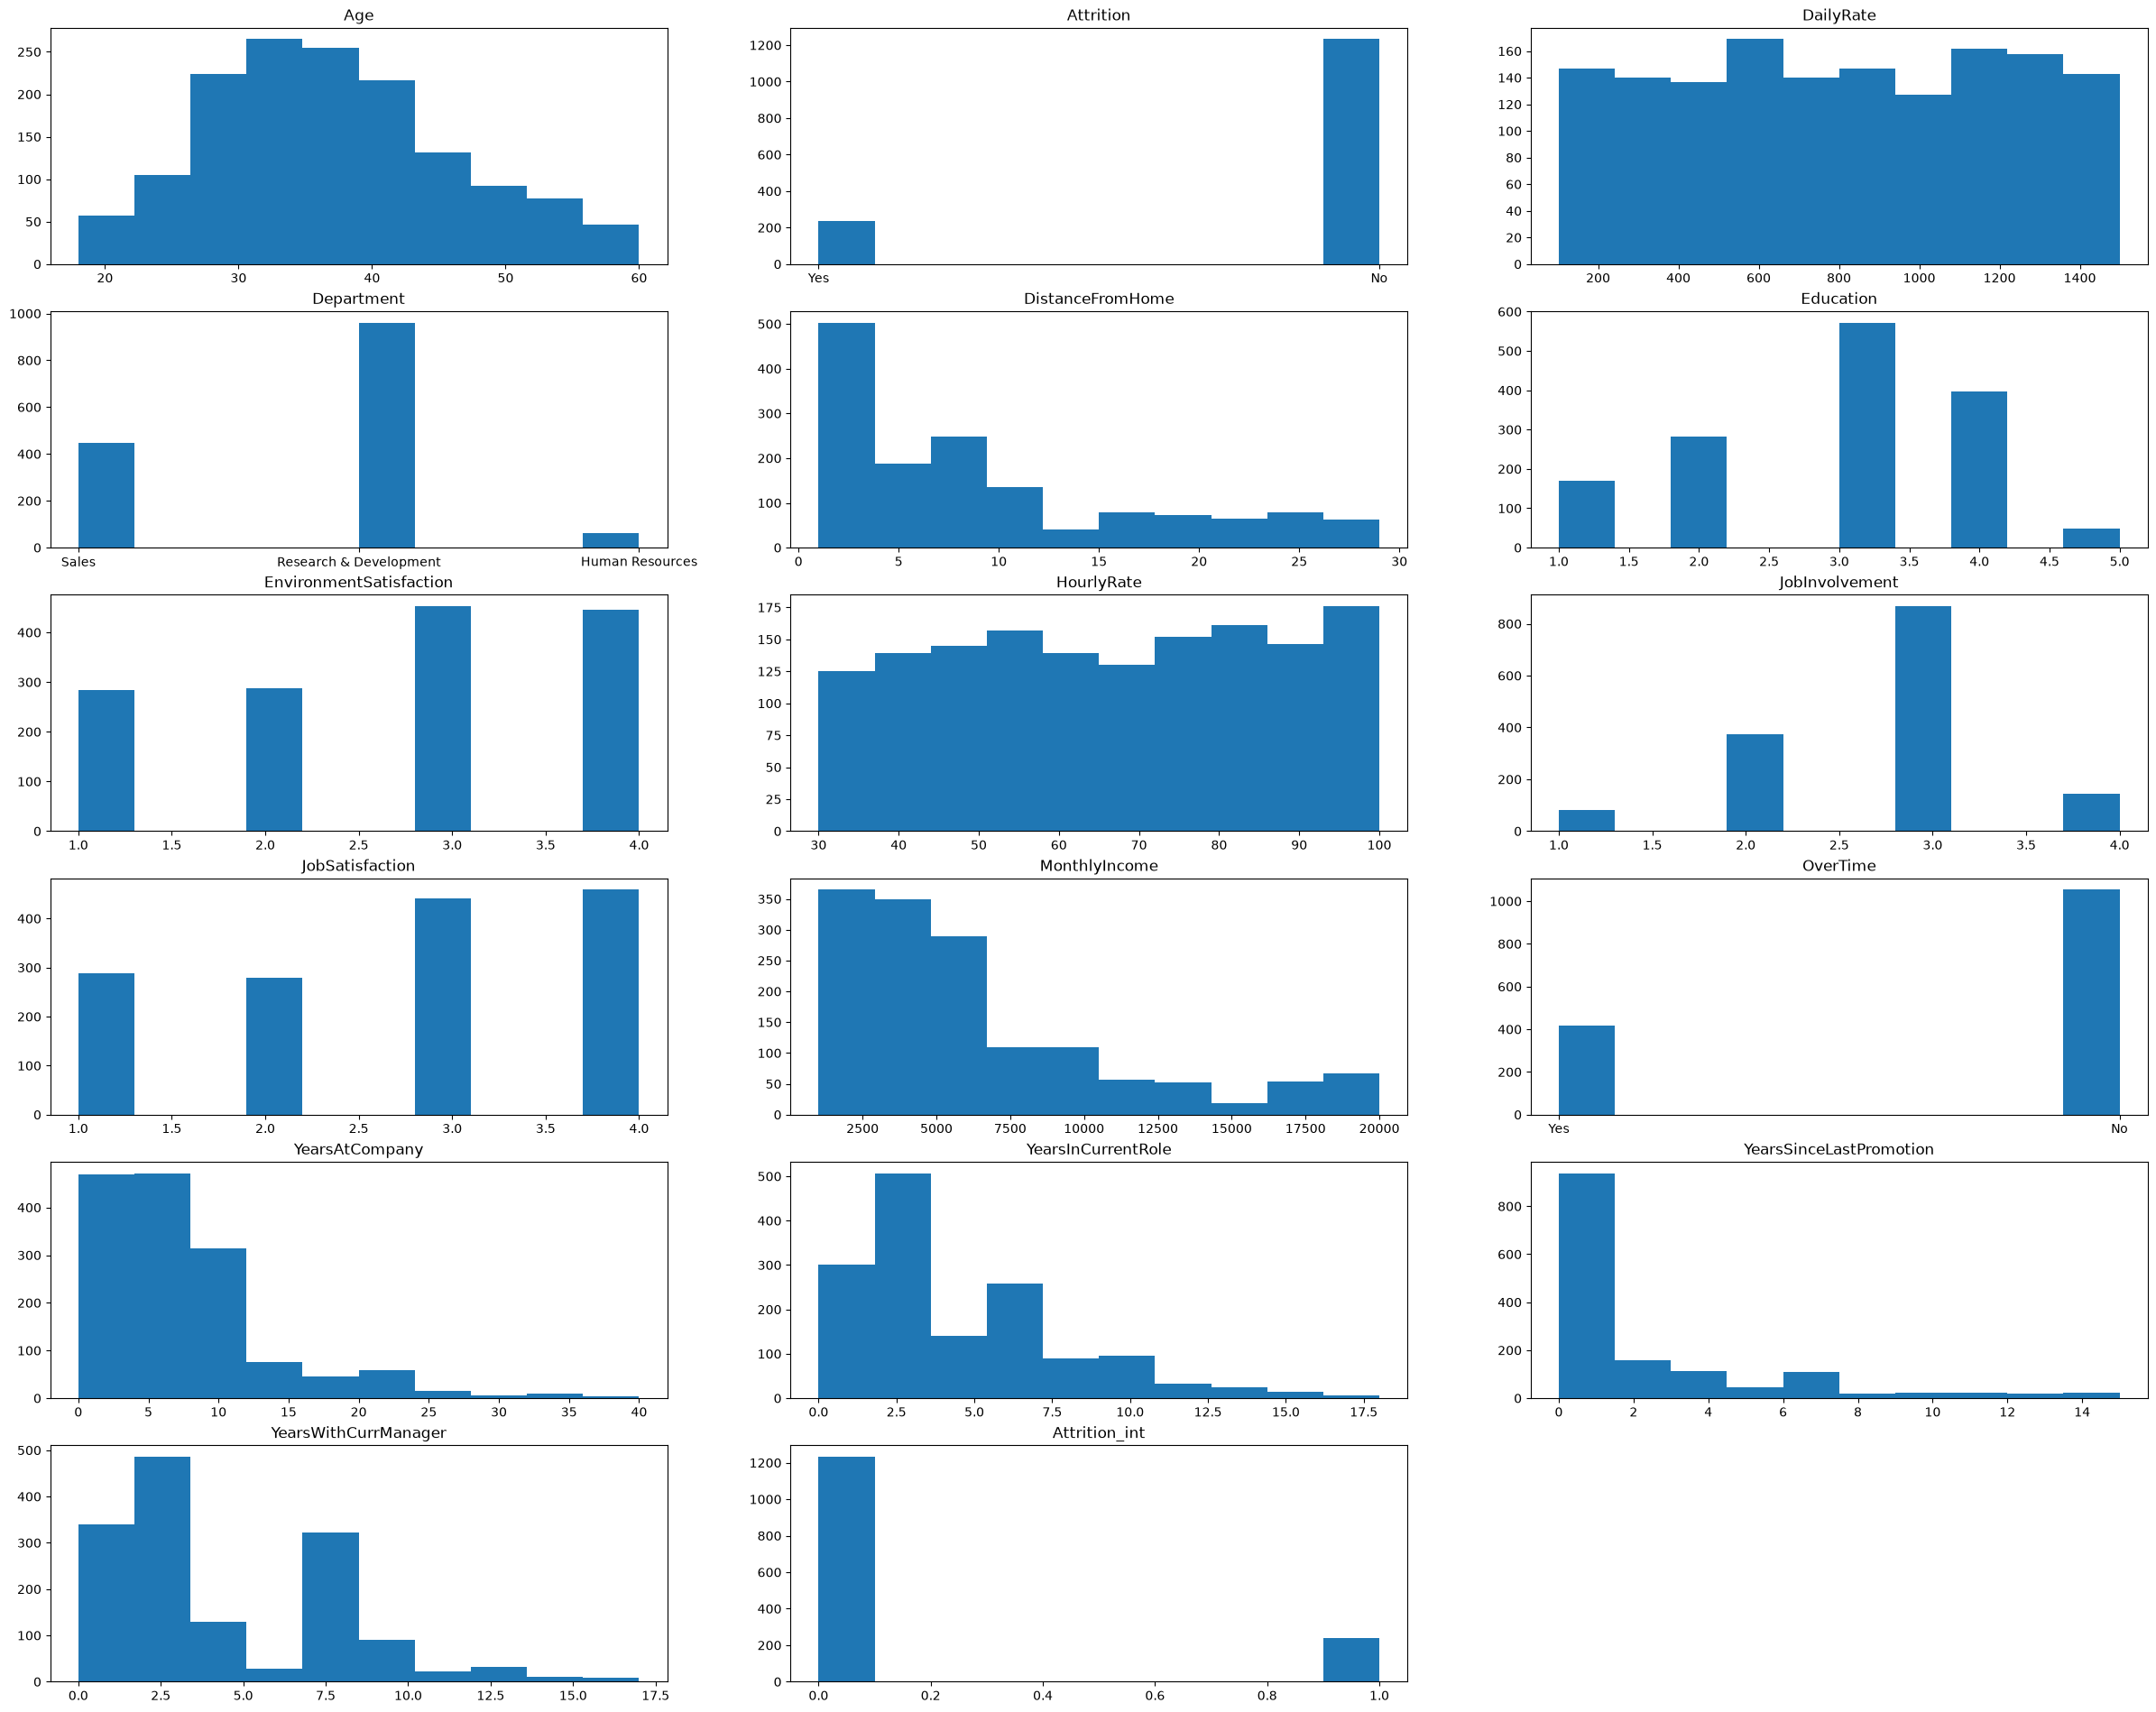

In [13]:
#Visualisation de la distribution de nos données : 

distribution(df, 30, 6000)

Ce graphique illustre les distributions de nos données. 
Ainsi, nous pouvons visualiser que peu de données suivent une répartition normales, aiguillant les choix de nos outils statistiques pour la suite de l'analyse. 

In [14]:
#Exploration du potentiel lien statistique entre JobSatisfaction et EnvironnementSatisfaction : 

corrcoef= np.corrcoef(df['JobSatisfaction'], df['EnvironmentSatisfaction'])

print(corrcoef[1,0])

-0.006784352599075022


<Axes: xlabel='JobSatisfaction'>

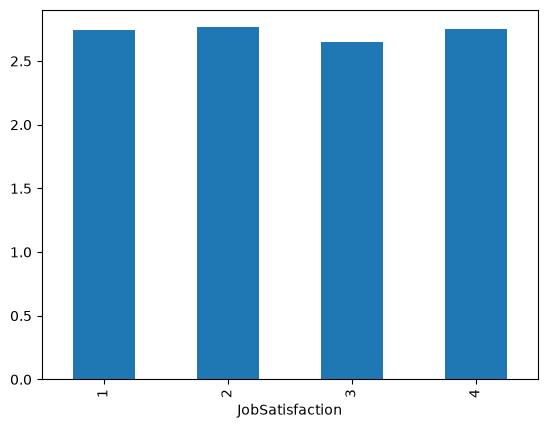

In [15]:
df.groupby('JobSatisfaction')['EnvironmentSatisfaction'].mean().plot(kind='bar')

On observe une indépendance statistique des valeurs JobSatisfaction et EnvironnementSatisfaction

In [16]:
#verification du lien statistique entre hourlyrate et dailyrate : 

corrcoef_HR = np.corrcoef(df['HourlyRate'], df['DailyRate'])

print(corrcoef_HR[1,0])

0.023381421528320293


<Axes: xlabel='HourlyRate'>

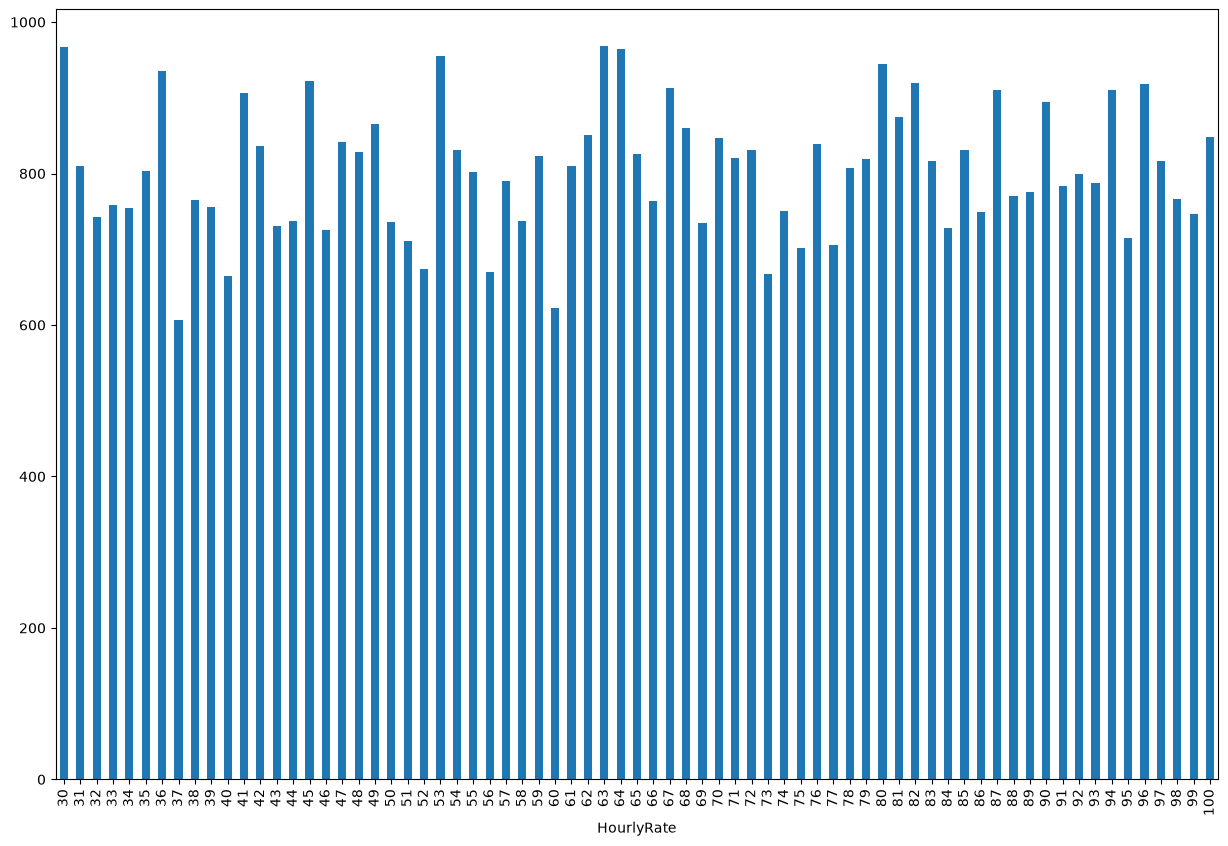

In [17]:
plt.figure(figsize=(15,10))
df.groupby('HourlyRate')['DailyRate'].mean().plot(kind='bar')

On observe une potentielle indépendance statistique entre les variables HourlyRate et DailyRate

In [18]:
#Segmentation de nos catégories pour avoir une équivalence numérique -> catégorielle

    #age : 

df['Age'].describe()


count    1470.000000
mean       36.923810
std         9.135373
min        18.000000
25%        30.000000
50%        36.000000
75%        43.000000
max        60.000000
Name: Age, dtype: float64

<Axes: ylabel='Age'>

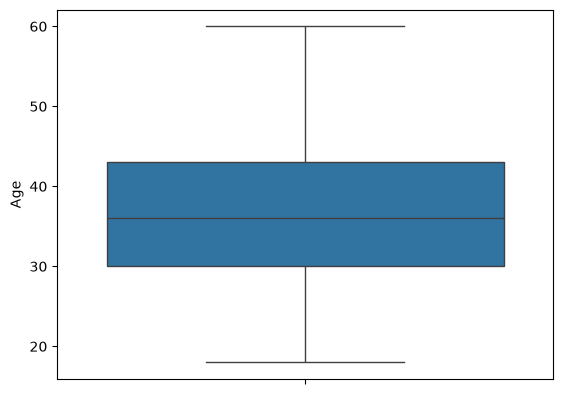

In [19]:
sns.boxplot(df['Age']) #visualisation de la répartition

Le graphique illustre les répartition démontrée dans le .describe(). Ceci nous permet alors de choisir une segmentation par quartiles tel que : 

* Min - Q1 = Catégorie 1

* Q1 - Q2 = Catégorie 2

* Q3 - Q4 = Catégorie 3 

* Q4 - Max = Catégorie 4

In [20]:
#Application de la fonction de segmentation de nos catégories : 

df['Age_str'] = df.apply(segmentation_age, axis = 1)

In [21]:
    #YearAtCompagny :

df['YearsAtCompany'].describe() 

count    1470.000000
mean        7.008163
std         6.126525
min         0.000000
25%         3.000000
50%         5.000000
75%         9.000000
max        40.000000
Name: YearsAtCompany, dtype: float64

<Axes: ylabel='YearsAtCompany'>

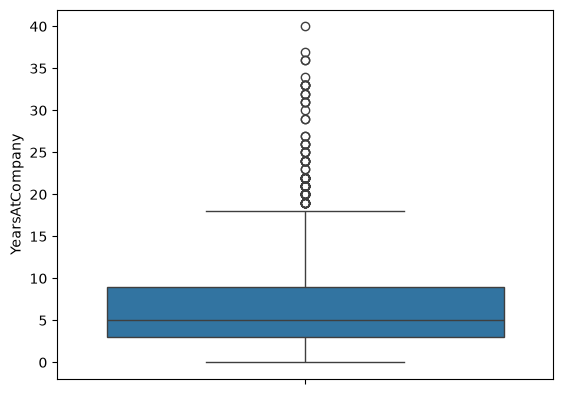

In [22]:
sns.boxplot(df['YearsAtCompany'])

Le graphique illustre les répartition démontrée dans le .describe(). Ceci nous permet alors de choisir une segmentation par quartiles tel que : 

* Min - Q1 = Catégorie 1

* Q1 - Q2 = Catégorie 2

* Q3 - Q4 = Catégorie 3 

* Q4 - Max = Catégorie 4

In [23]:
#Application de la fonction de segmentation du YatC : 

df['YearsAtCompany_str'] = df.apply(segmentation_yac, axis =1)

In [24]:
    #YearsInCurrentRole :

df['YearsInCurrentRole'].describe()

count    1470.000000
mean        4.229252
std         3.623137
min         0.000000
25%         2.000000
50%         3.000000
75%         7.000000
max        18.000000
Name: YearsInCurrentRole, dtype: float64

<Axes: ylabel='YearsInCurrentRole'>

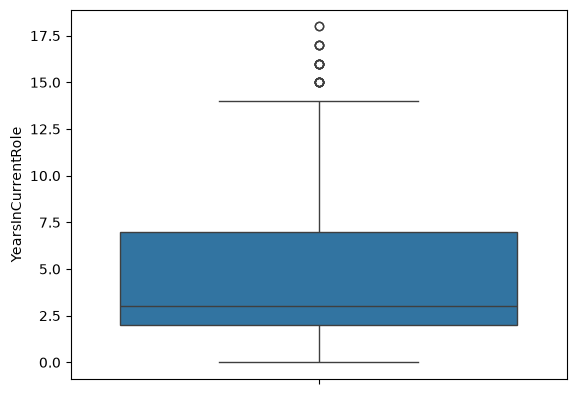

In [25]:
sns.boxplot(df['YearsInCurrentRole'])

Le graphique illustre les répartition démontrée dans le .describe(). Ceci nous permet alors de choisir une segmentation par quartiles tel que : 

* Min - Q1 = Catégorie 1

* Q1 - Q2 = Catégorie 2

* Q3 - Q4 = Catégorie 3 

* Q4 - Max = Catégorie 4

In [26]:
#Application de la fonction de segmentation sur YearsInCurrentRole_str

df['YearsInCurrentRole_str'] = df.apply(segmentation_yar, axis =1)

In [27]:
#Segmentation de DistanceFromHome : 

df['DistanceFromHome_str'] = pd.cut(
    df['DistanceFromHome'],
    bins=[0, 5, 10, 15, 20, 25, 30],
    labels=['0-5 km', '6-10 km', '11-15 km', '16-20 km', '21-25 km', '26-30 km']
)

In [28]:
#Segmentation de YearsSinceLastPromotion : 

df['YearsSinceLastPromotion'].describe()

count    1470.000000
mean        2.187755
std         3.222430
min         0.000000
25%         0.000000
50%         1.000000
75%         3.000000
max        15.000000
Name: YearsSinceLastPromotion, dtype: float64

<Axes: ylabel='YearsSinceLastPromotion'>

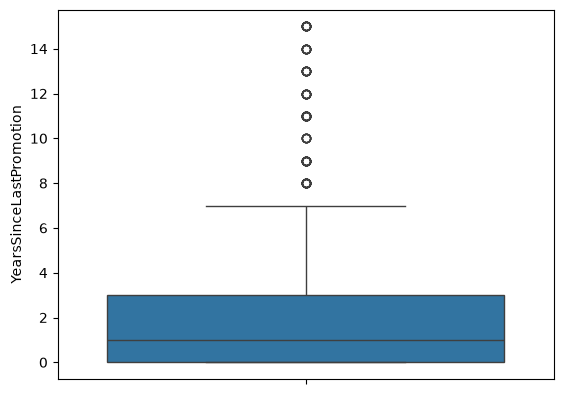

In [29]:
sns.boxplot(df['YearsSinceLastPromotion'])

La répartition par quartile n'est pas possibile sur cette catégorie.

Ainsi, nous allons couper sur 3 catégories : 

* 0 - 4 ans

* 5 - 8 ans

* 9 - 14 ans

In [30]:
df['YearsSinceLastPromotion_str'] = df.apply(segmentation_promo, axis=1) #application de la fonction de segmentation

In [31]:
#Segmentation de YearsWithCurrManager : 

df['YearsWithCurrManager'].describe()

count    1470.000000
mean        4.123129
std         3.568136
min         0.000000
25%         2.000000
50%         3.000000
75%         7.000000
max        17.000000
Name: YearsWithCurrManager, dtype: float64

<Axes: ylabel='YearsWithCurrManager'>

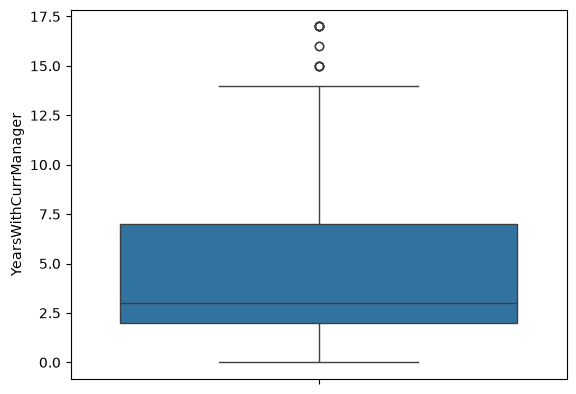

In [32]:
sns.boxplot(df['YearsWithCurrManager'])

Le graphique illustre les répartition démontrée dans le .describe(). Ceci nous permet alors de choisir une segmentation par quartiles tel que : 

* Min - Q1 = Catégorie 1

* Q1 - Q2 = Catégorie 2

* Q3 - Q4 = Catégorie 3 

* Q4 - Max = Catégorie 4

In [33]:
df['YearsWithCurrManager_str'] = df.apply(segmentation_ywcm, axis=1)

Après la segmentation de nos données essentielles, nous avons à notre disposition des variables qualitative permettant ensuite une analyse groupée des données.

A présent, nous allons réaliser l'évaluation des outliers afin de comprendre certaines données.

<Axes: >

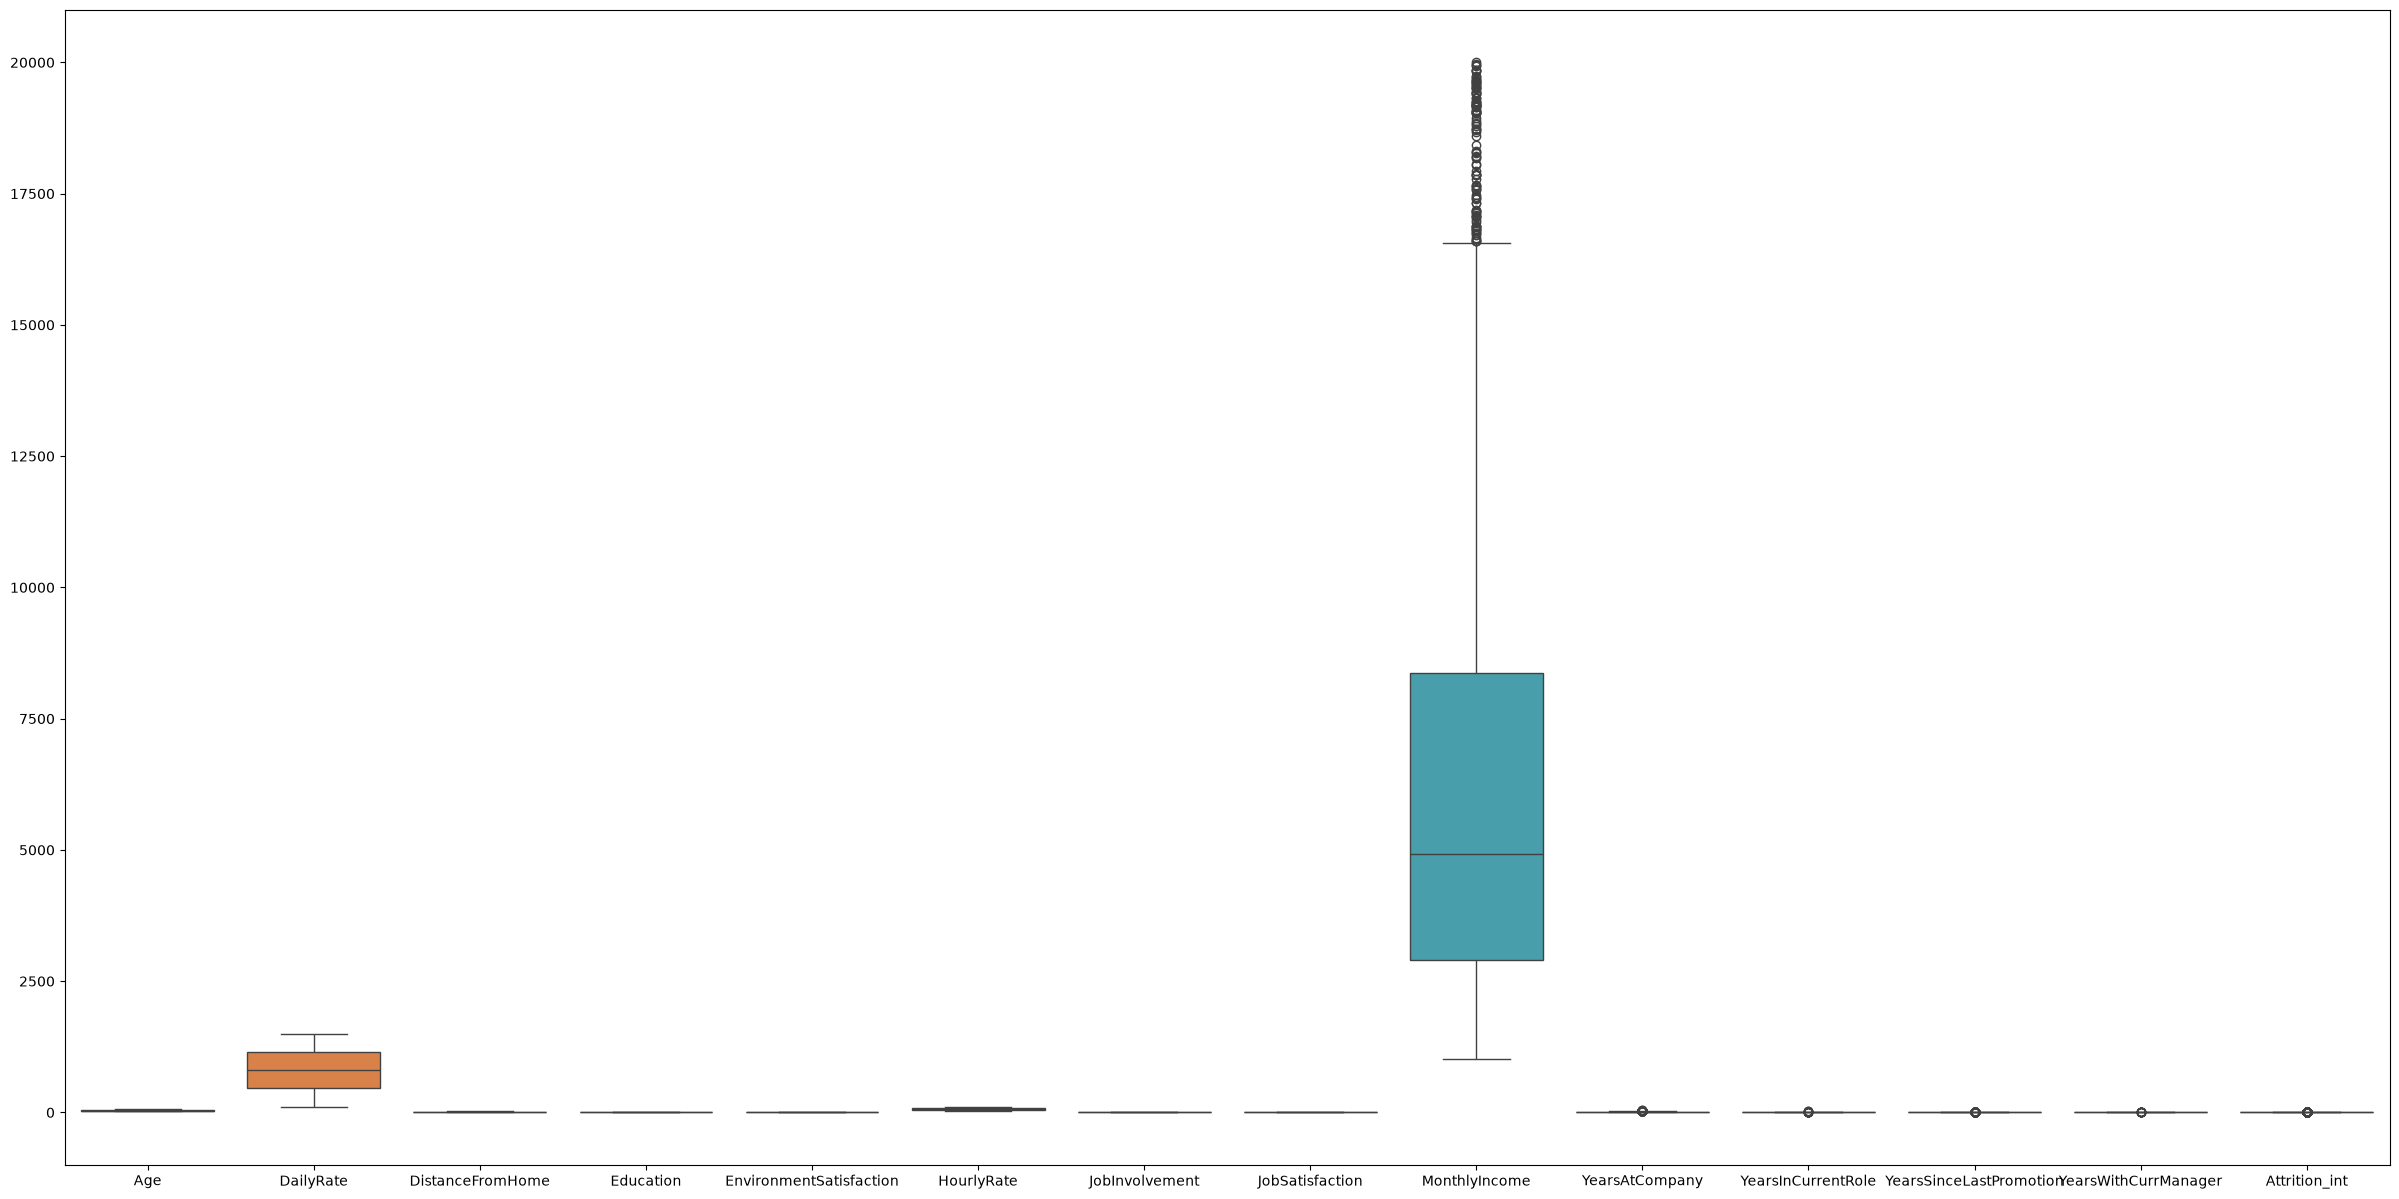

In [34]:
#Identification des outlier par BoxPlot

plt.figure(figsize=(30,15)) #création du canva
sns.boxplot(df) #affichage via seaborn

Cette vision globale expose des outliers sur 5 de nos données tel que : 

* MonthlyIncome

* YearsAtCompany

* YearsInCurrentRole

* YearsSinceLastPromotion

* YearsWithCurrManager

Nous excluons Attrition_int car cette variable créer par nos soin n'est pas intéressant pour les outliers.

In [35]:
df1 = df['MonthlyIncome'] #catégorisation par outlier identifié pour affichage graphique.
df2 = df['YearsAtCompany']
df3 = df['YearsInCurrentRole']
df3 = df['YearsSinceLastPromotion']
df4 = df['YearsWithCurrManager']


<Axes: ylabel='MonthlyIncome'>

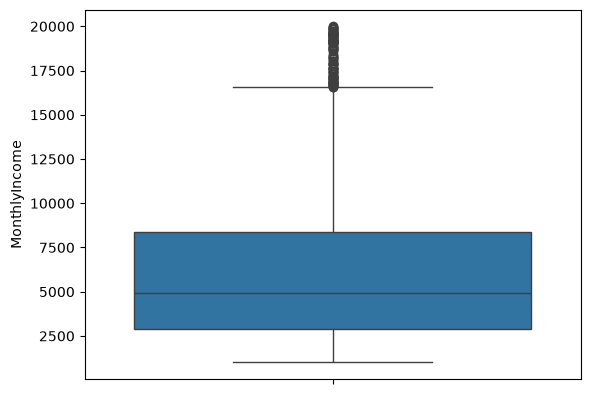

In [36]:
sns.boxplot(df1) #outlier 1

Ce BoxPlot confirme l'analyse globale, la donnée MonthlyIncome possède bien un ensemble d'outliers.

En terme métier, certains salariés en fonction de leur ancienneté ou de leurs actions peuvent gagner plus, expliquant alors la cause de ces valeurs abbérantes. 

<Axes: ylabel='YearsAtCompany'>

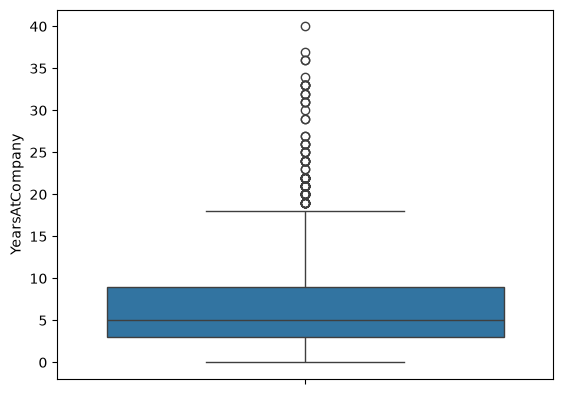

In [37]:
sns.boxplot(df2) #outlier 2

Ce BoxPlot confirme l'analyse globale, la donnée YearsAtCompany possède bien un ensemble d'outliers.

En terme métier, certains salariés peuvent rester de longues années au sein de la même sociéte, expliquant alors la cause de cette valeur abbérante. 

<Axes: ylabel='YearsSinceLastPromotion'>

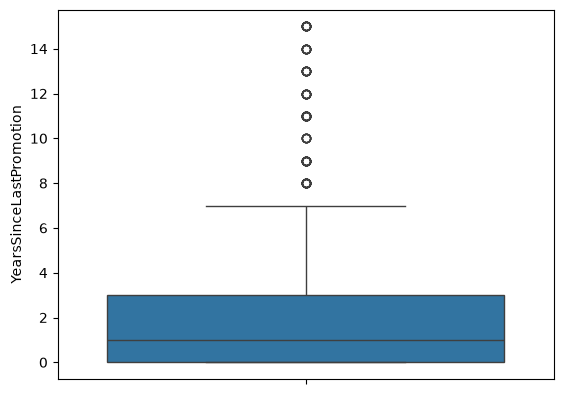

In [38]:
sns.boxplot(df3) #outlier 3

Ce BoxPlot confirme l'analyse globale, la donnée YearsSinceLastPromotion possède bien un ensemble d'outliers.

En terme métier, dans certains département des entreprises, ou en cas de poste déjà au plus haut de la hiérarchie, les promotions se font rare, expliquant pourquoi nous obtenons des valeurs si élevées. 

<Axes: ylabel='YearsWithCurrManager'>

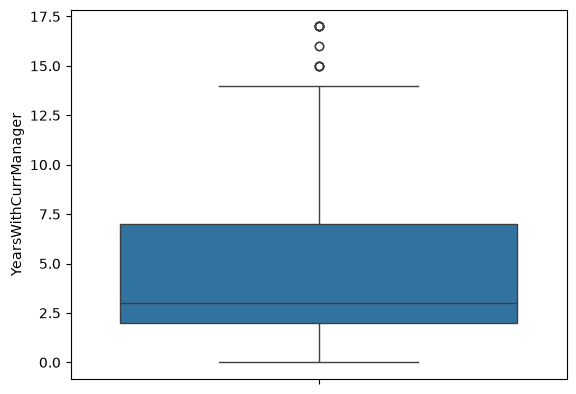

In [39]:
sns.boxplot(df4) #outlier 4

Ce BoxPlot confirme l'analyse globale, la donnée YearsWithCurrManager possède bien un ensemble d'outliers.

En terme métier, dans certains département, les managers restent longtemps en poste (cf. la partie du le YearsAtCompany), expliquant ainsi pourquoi certains employés passent aussi longtemps avec le même chef. 

L'analyse des valeurs abbérantes, démontre une bonne qualité de notre base de données. 

Cependant la présence de ces dernières sur 4 séries nous impose dès lors de ne faire usage que de la médiane lors de l'analyse de ces dernières, afin de limiter le poids statistiques de ces valeurs. 


A présent, nous allons nous concentrer sur la phase finale de notre EDA : la corrélation inter-variables. 

In [40]:
#evaluation des corrélations entre les datas : 

an_corr(df)


La corrélation entre Age et DailyRate est de 0.007289728044117844 (spearman)
La corrélation entre Age et Department est de 0.4652855299935297 (fisher = 0.7655031924976907)
La corrélation entre Age et DistanceFromHome est de -0.019290910985248558 (spearman)
La corrélation entre Age et HourlyRate est de 0.02885848516353823 (spearman)
La corrélation entre Age et MonthlyIncome est de 0.47190213023271405 (spearman)
La corrélation entre Age et YearsAtCompany est de 0.2516859699509598 (spearman)
La corrélation entre Age et YearsInCurrentRole est de 0.19797756100400973 (spearman)
La corrélation entre Age et YearsSinceLastPromotion est de 0.17364722381680112 (spearman)
La corrélation entre Age et YearsWithCurrManager est de 0.19481758412797956 (spearman)
La corrélation de Attrition et Department est de 0.004525606574479633 (chi2 = 10.79600732241067, dof = 2)
La corrélation de Attrition et Education est de 0.5455253376565949 (chi2 = 3.0739613982367193, dof = 4)
La corrélation de Attrition et Env

Nous pouvons observer l'ensemble des corrélations entre nos variables, ainsi que la méthode d'analyse utilisée.

In [41]:
df_corr = df.drop(['Age_str', 'YearsAtCompany_str', 'YearsInCurrentRole_str', 'Attrition', 'Department', 'OverTime'], axis=1) #drop des colonnes 'strings' pour l'analyse en heatmap sns

<Axes: >

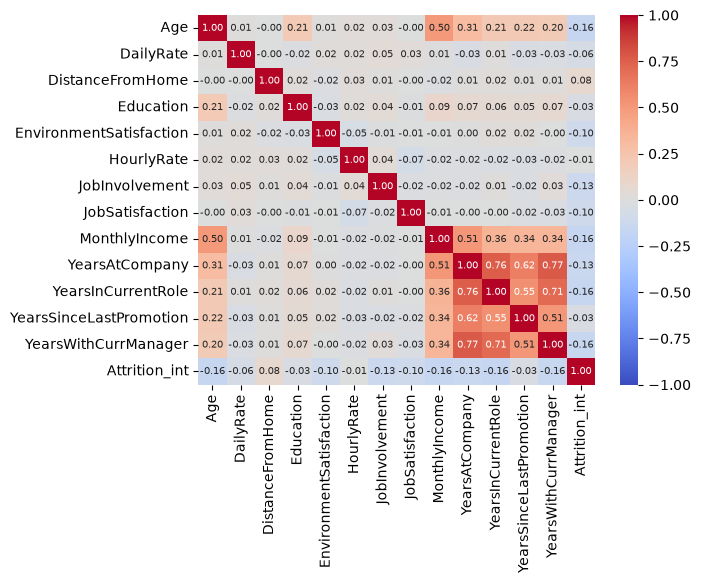

In [42]:
corr_matrix = df_corr.corr(numeric_only=True) #création de la matrice de corrélation

plt.Figure(figsize=(18,15))
sns.heatmap(corr_matrix, annot=True,  cmap='coolwarm',fmt='.2f', vmin=-1, vmax=1, annot_kws={"size": 7}) #affichage de la heatmap

NOTE IMPORTANTE : Cette heatmap bien que traduisant des corrélation est à prendre avec des précautions particulières :

* Elle n'évalue que par le coefficient de Pearson, et ne tient pas compte de la distribution de nos données

Ainsi les données traduites peuvent être de moins bonne qualité, mais donne une visualisation d'ensemble constructive

In [43]:
#Comprehension en profondeur des potentielles causes des corrélations : 

df.groupby('Age_str').MonthlyIncome.agg(['median', 'min', 'count'])

,median,min,count
Age_str,,,
18 - 30 ans,2938.5,1009,326
31 - 36 ans,4682.0,1081,403
37 - 43 ans,5583.5,1702,362
44 - 60 ans,8865.0,2011,379


On observe bien que les salariés les plus agés ont un salaire médian plus élevé que les plus jeunes.

Cette différence peut s'expliquer par le facteur d'ancieneté qui pourrait faire augmenter le salaire des salariés plus anciens.

Ainsi, nous allons explorer cette piste : 

In [44]:
age_corr = df.groupby(['YearsAtCompany_str','Age_str']).MonthlyIncome.agg(['median', 'min', 'count'])
age_corr.sort_values(by='median', ascending=True)

median    min  count
YearsAtCompany_str Age_str                           
0 à 5 ans          18 - 30 ans   2704.5   1009    236
                   31 - 36 ans   3479.0   1081    197
6 à 10 ans         18 - 30 ans   4558.0   2058     87
0 à 5 ans          37 - 43 ans   4671.5   1702    168
11 à 20 ans        31 - 36 ans   5468.0   2028     61
6 à 10 ans         31 - 36 ans   5505.0   2022    145
0 à 5 ans          44 - 60 ans   5562.0   2042    175
6 à 10 ans         37 - 43 ans   5673.0   2088    105
                   44 - 60 ans   7260.0   2011    111
11 à 20 ans        18 - 30 ans   7336.0   3812      3
                   37 - 43 ans   8823.0   2115     69
                   44 - 60 ans  13320.0   2348     47
+ de 20 ans        44 - 60 ans  17002.5   5210     46
                   37 - 43 ans  18655.0  10447     20

On observez bien que les salariés avec le plus d'ancieneté ont un salaire médian plus élevés que ceux présent depuis moins longtemps, confirmant ainsi notre hypothèse. 

In [45]:
df.groupby(['Attrition', 'Department']).Department.describe()


count unique                     top freq
Attrition Department                                                      
No        Human Resources           51      1         Human Resources   51
          Research & Development   828      1  Research & Development  828
          Sales                    354      1                   Sales  354
Yes       Human Resources           12      1         Human Resources   12
          Research & Development   133      1  Research & Development  133
          Sales                     92      1                   Sales   92

On observe bien un lien entre l'attrition et le département dans lequel évolue le salarié.
Ceci peut se nuancer au regard de l'effectif bien plus faible dans la catégorie "Yes"

Cette phase d'EDA se conclue par la visualition de plusieurs éléments clés liés à notre questions initiale.

L'évaluation de la corrélation nous a démontré des potentiels liens statistiques entre certaines données, nous permettant de nuancer l'analyse à suivre.

Cependant il est important de mentionner que certaines de ces corrélations peuvent être lié au hasard ou bien à d'autres variables explicatives. 

Nous allons à présent passer à la dernière phase de notre analyse, la compréhension des causes réelles de l'attrition au sein de cette entreprise. 

Pour ce faire, nous allons procéder à l'analyse variable par variable de leur lien avec l'attrition

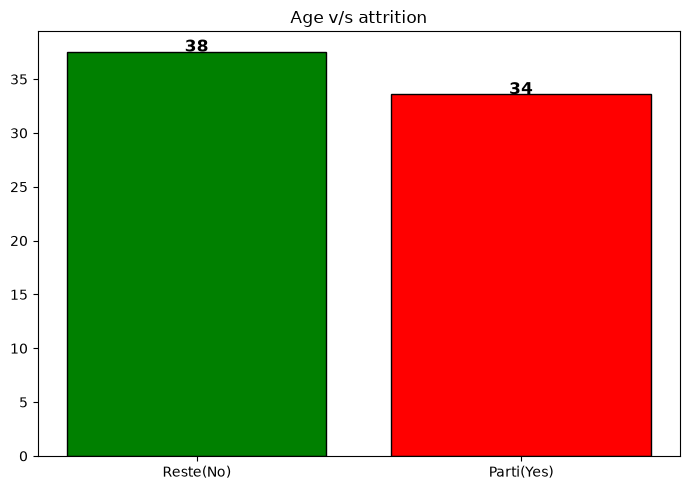

In [46]:
#comparaison age / attrition : 

average_age = df.groupby('Attrition')['Age'].mean()
plot_bar(average_age, "Age", 0)#creation du graphique

Ce graphique illustre que les salariés partant sont plus jeunes que ceux qui restent.

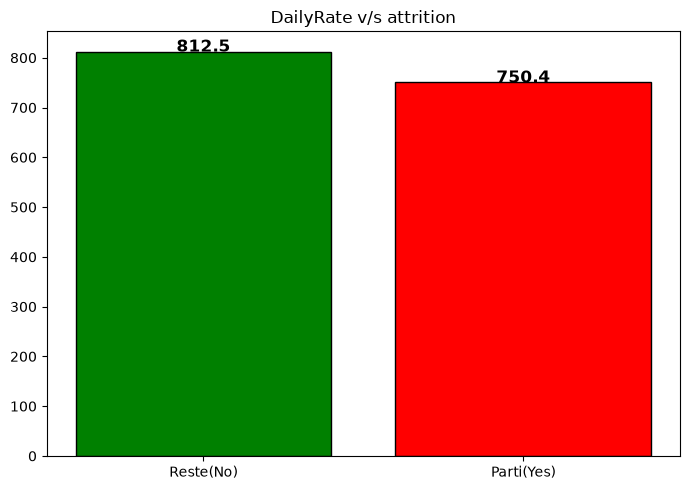

In [47]:
#comparaison daily / attrition : 

average_dr = df.groupby('Attrition')['DailyRate'].mean()
plot_bar(average_dr, "DailyRate", 1)

On peux observer que les salariés quittant l'entreprise possèdent un Taux Journalier inférieur aux salariés restants, illustrant une potentielle cause de départ. 

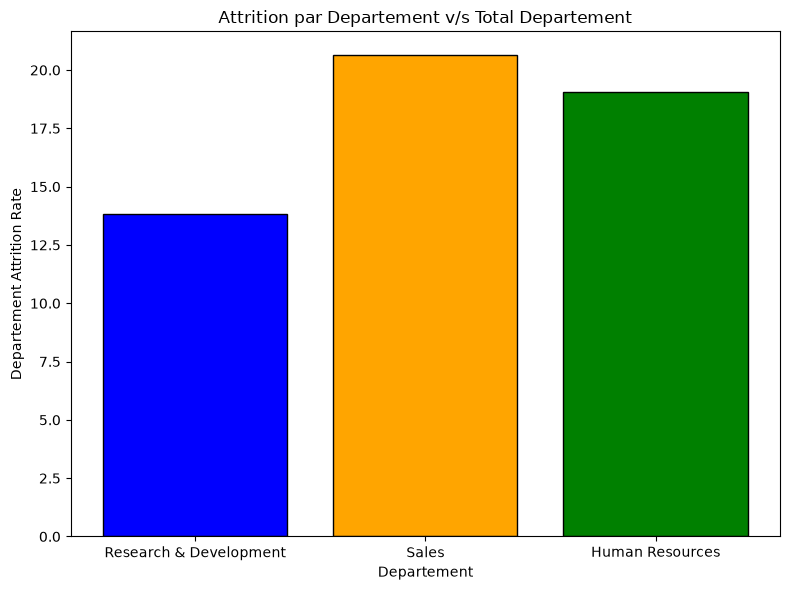

In [48]:
#Comparaison par département :

dep = df['Department'].value_counts()

dp_quit = df[df['Attrition'] == 'Yes']['Department'].value_counts()

dp_attritionrate = (dp_quit/dep)*100

#Création du graphique : 

plt.figure(figsize=(8,6))
plt.bar(dp_attritionrate.index, dp_attritionrate.values, color=['Blue', 'Orange', 'Green'], edgecolor='Black')
plt.title('Attrition par Departement v/s Total Departement')
plt.xlabel('Departement')
plt.ylabel('Departement Attrition Rate')
plt.tight_layout()

Ce graphique illustre le lien entre le département de l'employé et son taux d'attrition. 
Ainsi, un département comme les Ventes (Sales) possèdent un taux plus élevé que la Recherche & Développement (Research & Development).

Nous allons à présent étudier les causes réelle de cette différence au regard de deux éléments : 

* Le niveau de revenu est-il différent des autres ? 

* Le niveau de satisfaction est-il le même ?

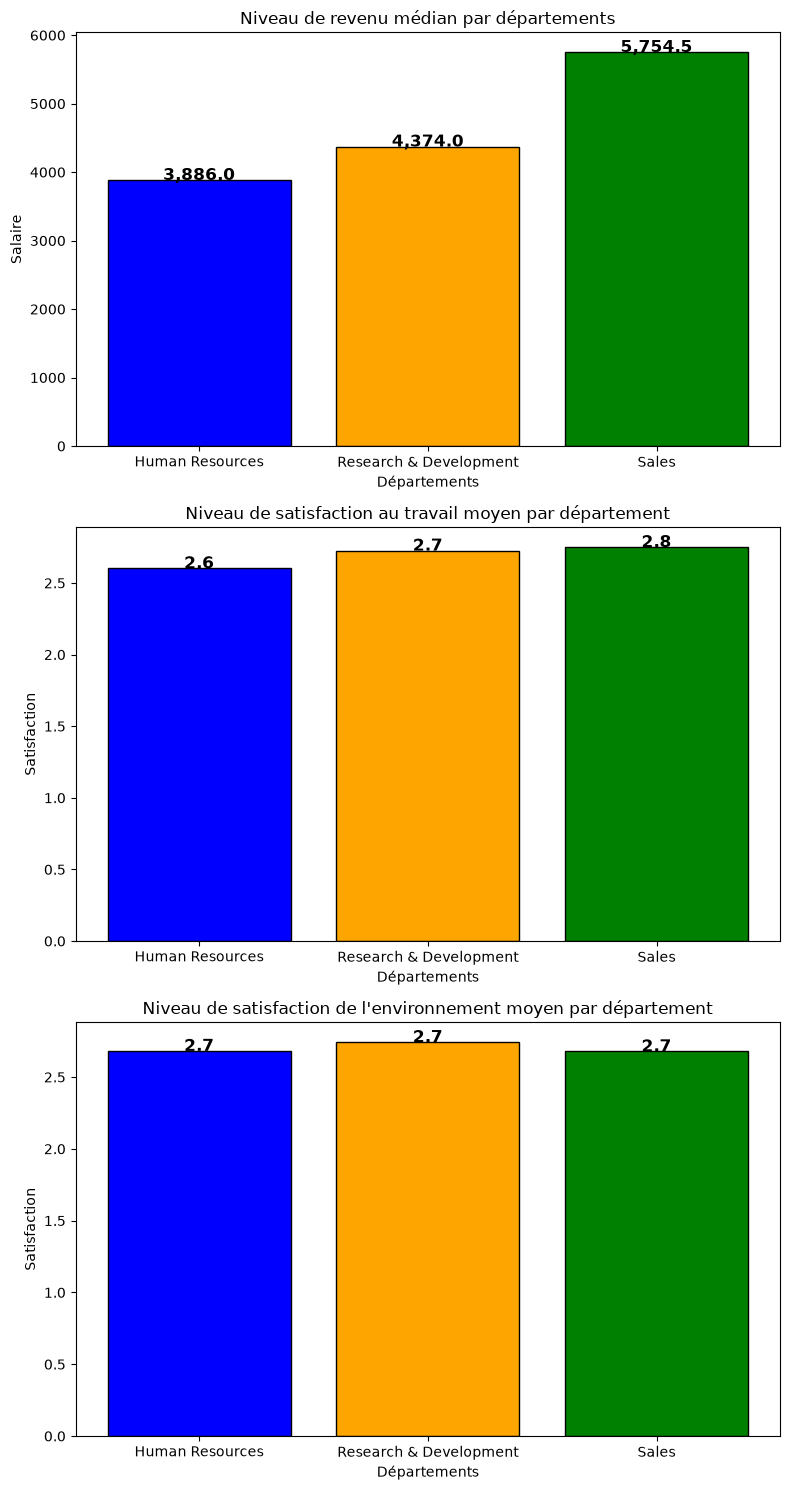

In [49]:
dp_income = df.groupby('Department')['MonthlyIncome'].median() #analyse du salaire moyen par départements

dp_satij = df.groupby('Department')['JobSatisfaction'].mean() #analyse de la satisfaction du travail

dp_satie = df.groupby('Department')['EnvironmentSatisfaction'].mean() #analyse de la satisfaction dans l'environnement de travail

#creation du graphique

plt.figure(figsize=(8,15))
plt.subplot(3, 1, 1)
plot_details(dp_income, "Niveau de revenu médian par départements", "Départements", "Salaire")
plt.subplot(3, 1, 2)
plot_details(dp_satij, "Niveau de satisfaction au travail moyen par département", "Départements", "Satisfaction")
plt.subplot(3, 1, 3)
plot_details(dp_satie, "Niveau de satisfaction de l'environnement moyen par département", "Départements", "Satisfaction")



Ce graphique illustre aucune explications majeure concernant les départs des sales comparés aux autres départements.
Cependant, nous allons devoir réaliser une analyse complète en y intégrant la notion d'attrition.

Nous conserverons les données précédemment analysée. 

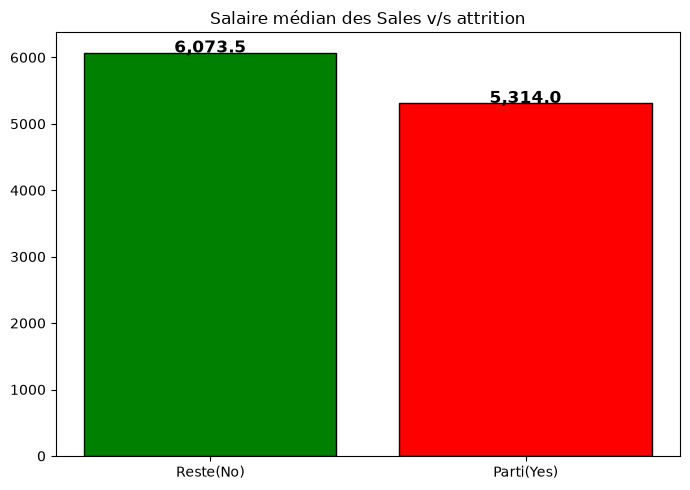

In [50]:
df_sales = df.loc[df['Department'] == "Sales"] #creation du dataframe "sales"

average_mh_sales = df_sales.groupby('Attrition')['MonthlyIncome'].median() #calcul du salaire médian d'un sales

average_env_sales = df_sales.groupby('Attrition')['EnvironmentSatisfaction'].mean() #calcul de la satisfaction moyenne d'un sales

average_js_sales = df_sales.groupby('Attrition')['JobSatisfaction'].mean()

#creation du plot Salaire
plot_bar(average_mh_sales, "Salaire médian des Sales", 1)

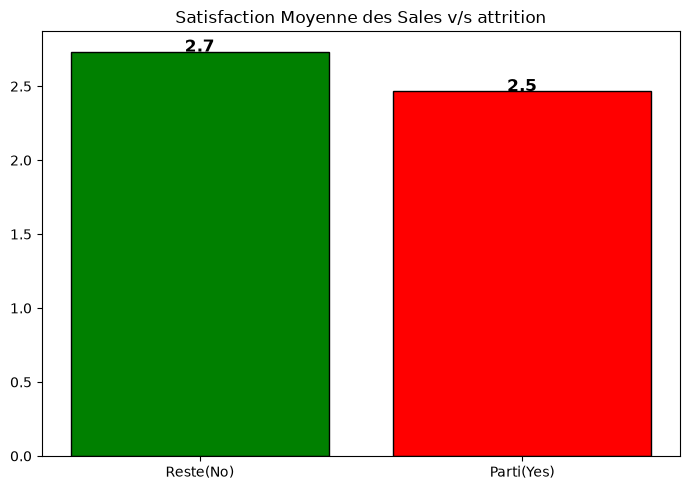

In [51]:
#creation du plot Satisfaction de l'environnement 

plot_bar(average_env_sales, "Satisfaction Moyenne des Sales", 1)

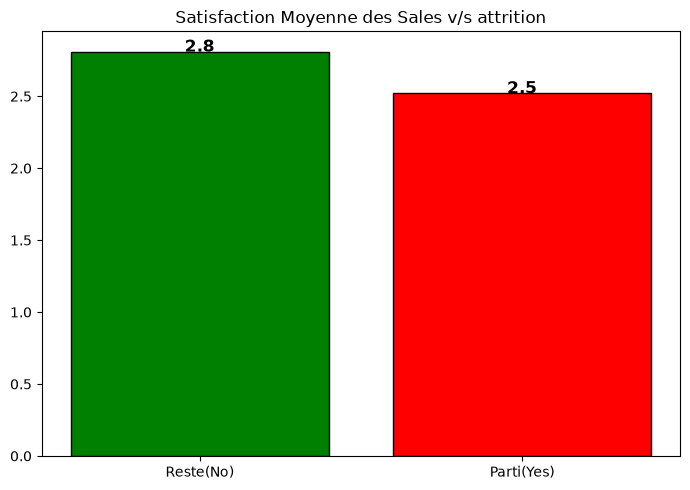

In [52]:
#creation du plot Satisfaction de l'environnement 

plot_bar(average_js_sales, "Satisfaction Moyenne des Sales", 1)

Ces graphiques n'illustrent pas d'écarts majeurs entre les données précédemment obtenues et celles des sales, ils possèdent même moins de facteurs explicatifs dans nos données.

Ainsi, nous ne pouvons apporter de conseils précis concernant ce département mais, toutefois nous devons appuyer sur le risque plus important de départ dans ce domaine.

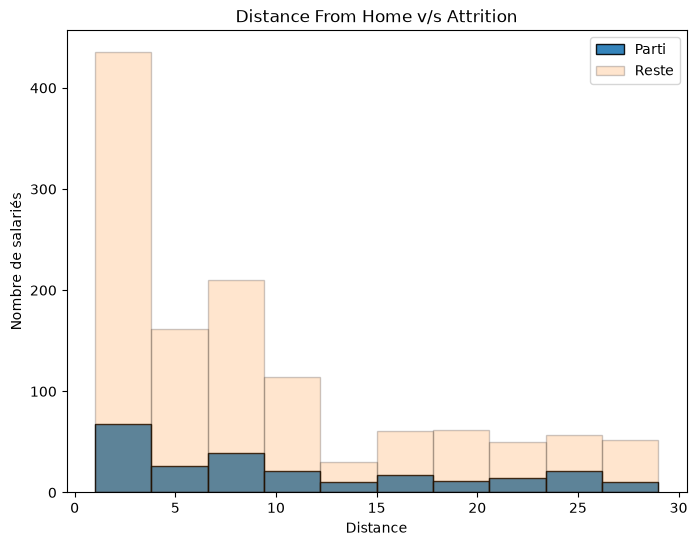

In [53]:
#Analyse du Distance From Home

quit_dist = df[df['Attrition'] == 'Yes']['DistanceFromHome']
stay_dist = df[df['Attrition'] == 'No']['DistanceFromHome']

plot_hist(quit_dist, stay_dist, "Distance From Home", "Distance", "Nombre de salariés") #creation du graphique

Ce graphique illustre l'impact de la distance entre le domicile et l'attrition. Ainsi, nous pouvons observer que les salariés habitant plus loin de leur lieu de travail ont tendance à quitter l'entreprise, comparé à ceux vivant proche.  

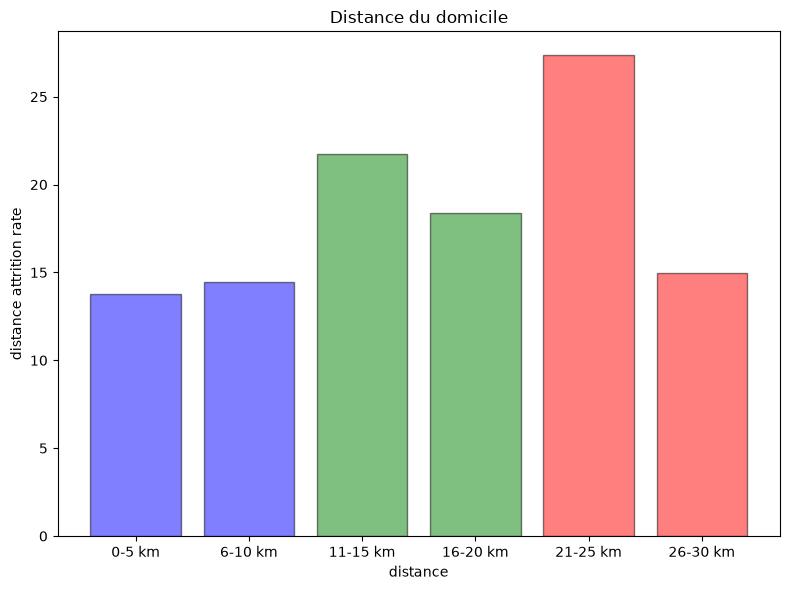

In [54]:
#Analyse de l'impact réel de la distance sur le taux d'attrition : 

dh = df['DistanceFromHome_str'].value_counts()
dh_quit = df[df['Attrition'] == 'Yes']['DistanceFromHome_str'].value_counts()
dh_attritionrate = (dh_quit/dh)*100

plot_analyse(dh_attritionrate, 'Distance du domicile', 'distance')

Ce graphique illustre l'impact réel de la distance sur le taux d'attrition dans l'entreprise.

L'on peut observer un pic entre 21 et 25 km. 

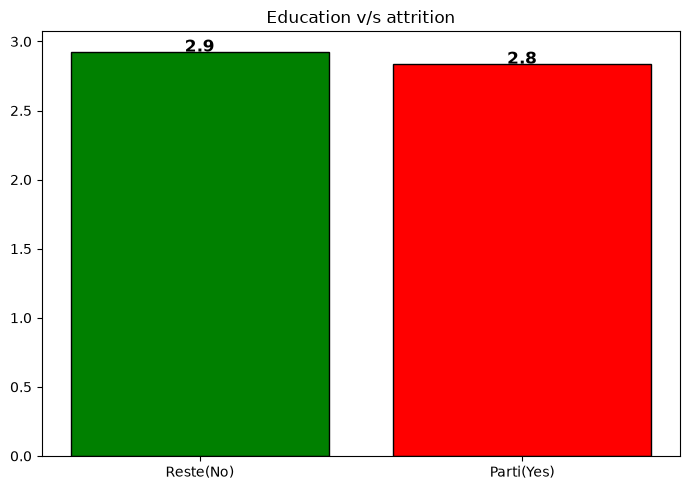

In [55]:
#comparaison Education / attrition : 

average_educ = df.groupby('Attrition')['Education'].mean()

plot_bar(average_educ, "Education", 1) #Creation du graphique

Le niveau d'étude semble avoir un effet statistiquement plus faible sur l'attrition au regard de la différence illustrée par le graphique ci dessus. 

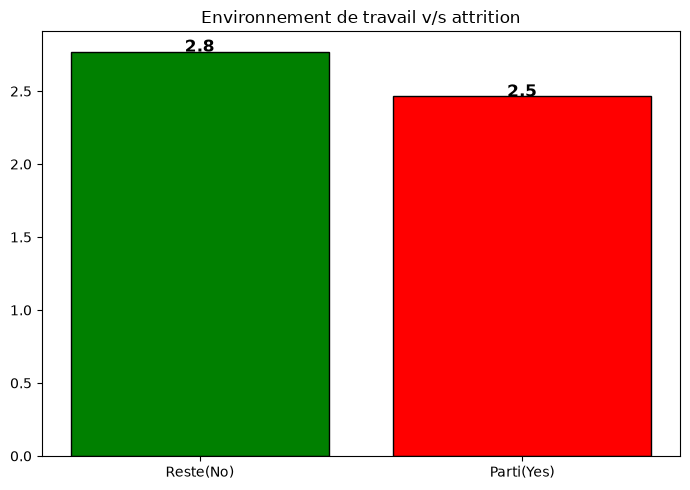

In [56]:
#comparaison EnvironmentSatisfaction / attrition

average_env = df.groupby('Attrition')['EnvironmentSatisfaction'].mean()

plot_bar(average_env, "Environnement de travail", 1) #création du graphique

Nous pouvons observer que statisfaction vis à vis de l'environnement de travail a un impact important sur les départs des salariés. 

Cependant ce poids est à remettre en perspective de la faible différence (0,3) entre les deux moyennes. 

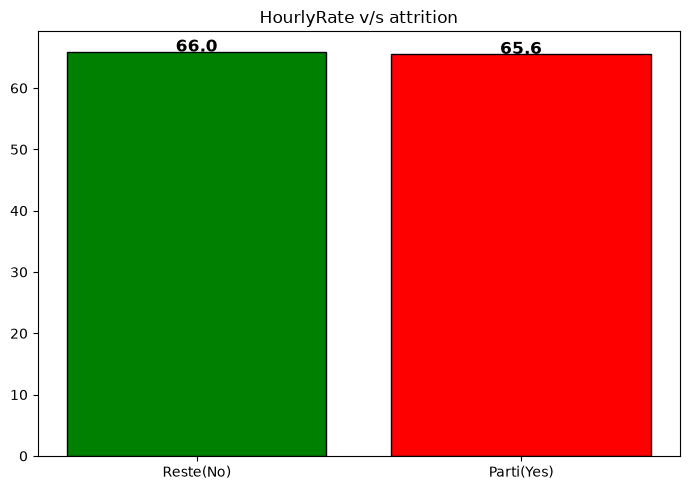

In [57]:
#comparaison HourlyRate / attrition

average_hr = df.groupby('Attrition')['HourlyRate'].mean()

plot_bar(average_hr, "HourlyRate", 1) #creation du graphique

Ce graphique illustre que le taux horaire ne posséderait pas d'impact sur le taux de départ des salariés au sein de l'entreprise.

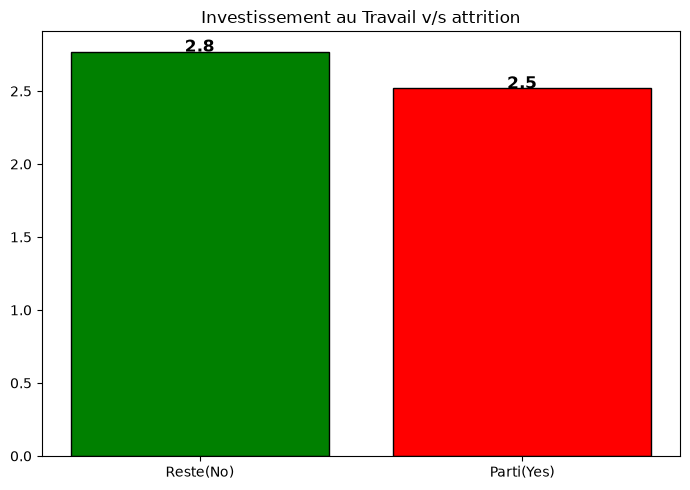

In [58]:
##comparaison JobInvolvement / attrition

average_ji = df.groupby('Attrition')['JobInvolvement'].mean()

plot_bar(average_ji, "Investissement au Travail", 1) #creation du graphique

Ce graphique illustre que les salariés ayant quittés l'entreprise possédaient une estimation plus faible de l'investissement au travail. 

Cette données au dela de potentiellement illustrer le départ de salariés moins investi, peut également traduire un impact psychologique plus profond.

Ainsi ces salariés seraient parti car il ne possèdaient pas la reconnaissance attendue de la part des managers.

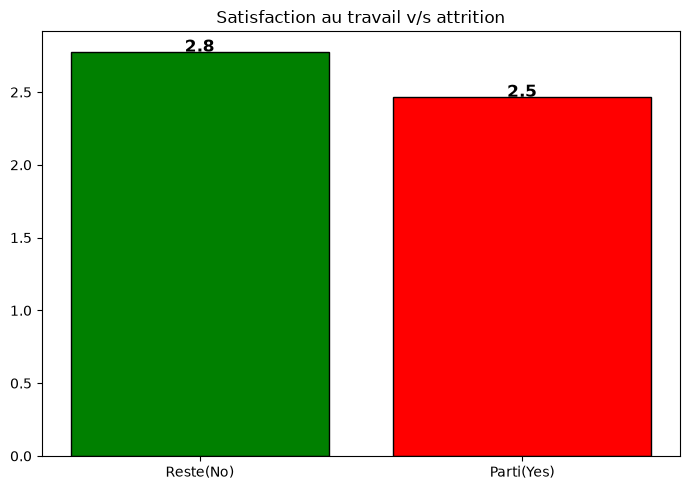

In [59]:
##comparaison JobSatisfaction / attrition

average_js = df.groupby('Attrition')['JobSatisfaction'].mean()

plot_bar(average_js, "Satisfaction au travail", 1) #creation du graphique

On observe que les salariés ayant quitté l'entreprise possédaient en moyenne une plus faible satisfaction vis à vis de leur travail. 

Ceci illustre une donnée sensible pour la prévention de l'attrition au sein de la société. 

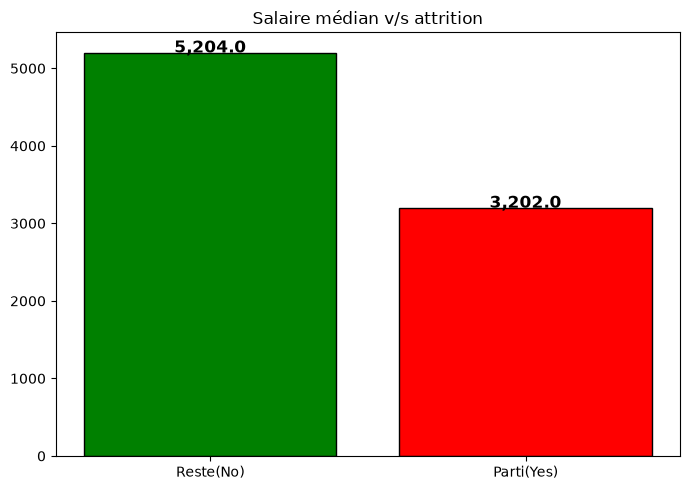

In [60]:
#comparaison MonthlyIncome / attrition

average_mh = df.groupby('Attrition')['MonthlyIncome'].median()

plot_bar(average_mh, "Salaire médian", 1) #creation du graphique

On observe que les salariés ayant quitté l'entreprise étaient moins bien payé que les autres. Dès lors, le départ pour cause monétaire peut être invoqué.

Cependant, le potentiel lien entre l'age et le salaire et le fait que les salariés ayant quitté l'entreprise étaient plus jeunes, peut traduire l'impact de l'ancieneté sur le fait ou non de rester plutôt que la simple raison monétaire.

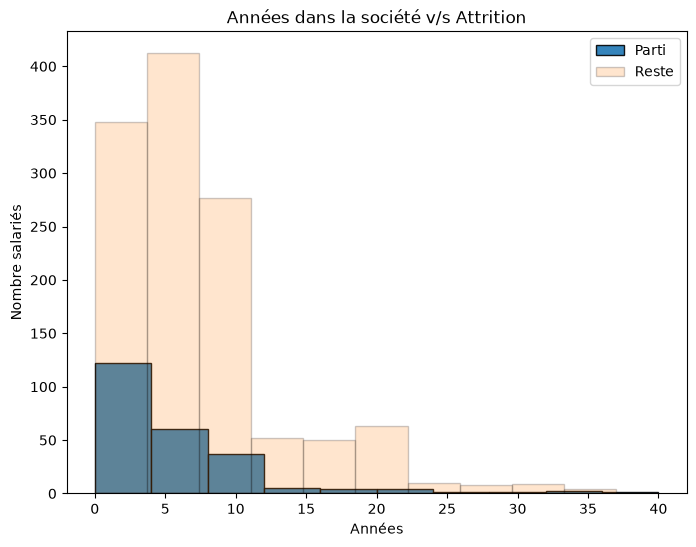

In [61]:
##comparaison YearsAtCompany / attrition

quit_yac = df[df['Attrition'] == 'Yes']['YearsAtCompany']
stay_yac = df[df['Attrition'] == 'No']['YearsAtCompany']

plot_hist(quit_yac, stay_yac, "Années dans la société", "Années", "Nombre salariés") #creation du graphique

Ce graphique illustre le lien entre l'attrition et les années au sein de l'entreprise. Il démontre que l'ancieneté aurait un potentiel lien sur le fait ou non de quitter l'entreprise. 

Ainsi, après 10 ans, les salariés ont plus tendance à rester qu'à partir. 

De plus, la notion de retraite est importante à souligner lorsque l'on dépasse les 20 ans d'ancienetés.

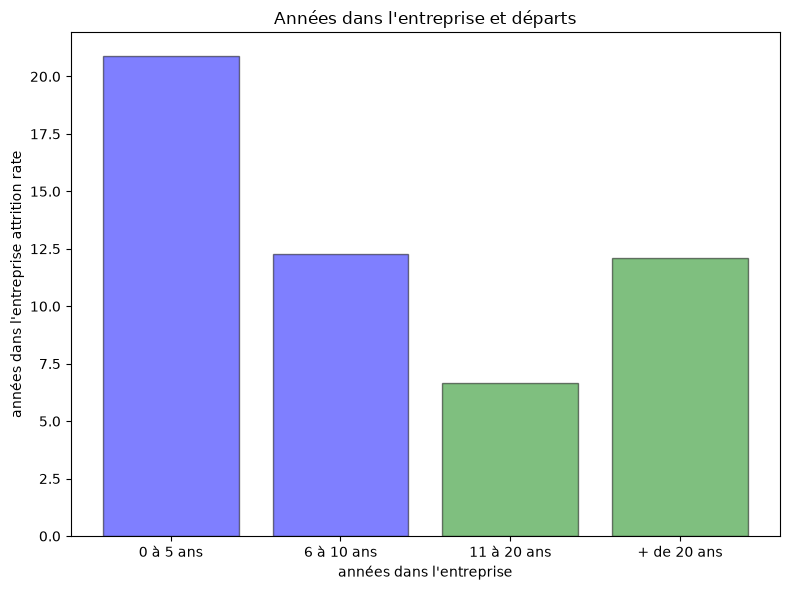

In [62]:
#Analyse de l'impact réel de l'ancienetée' sur le taux d'attrition : 

yc = df['YearsAtCompany_str'].value_counts()
yc_quit = df[df['Attrition'] == 'Yes']['YearsAtCompany_str'].value_counts()
yc_attritionrate = (yc_quit/yc)*100

plot_analyse(yc_attritionrate, "Années dans l'entreprise et départs", "années dans l'entreprise")

Ce graphique illustre plus précisément les années de départs des salariés.

Ainsi, autour de 0 à 5 ans, ils partent plus que les autres. 

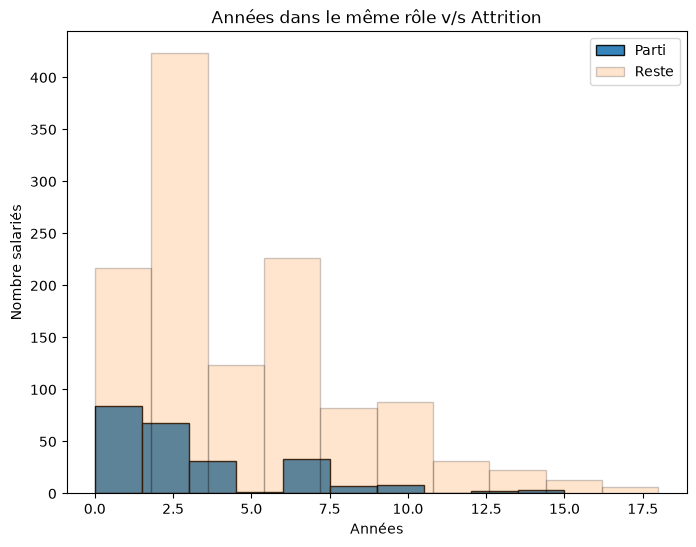

In [63]:
#comparaison YearsInCurrentRole / attrition

quit_yar = df[df['Attrition'] == 'Yes']['YearsInCurrentRole']
stay_yar = df[df['Attrition'] == 'No']['YearsInCurrentRole']

plot_hist(quit_yar, stay_yar, "Années dans le même rôle", "Années", "Nombre salariés") #creation du graphique

Ce graphique illustre le lien entre les années au même poste et le fait de rester dans l'entreprise. Ainsi, des salariés exposés au mêmes missions pendant plusieurs années ne semblent pas plus partir que les autres.

Cependant l'ont observe un pic au début de la courbe qui pourrait s'expliquer par une faible satisfaction du job ou de l'environnement (en cas de changement de département)

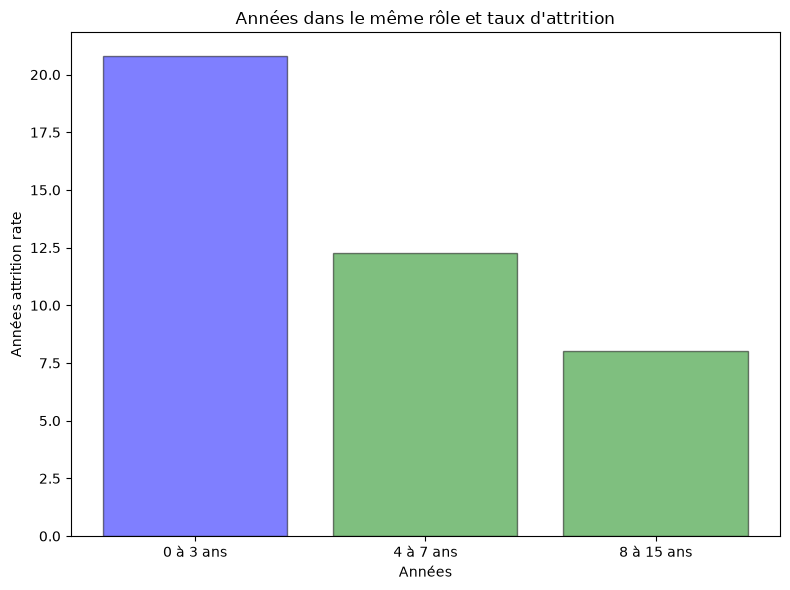

In [64]:
#Analyse en détail de la période critique : 

yr = df['YearsInCurrentRole_str'].value_counts()
yr_quit = df[df['Attrition'] == 'Yes']['YearsInCurrentRole_str'].value_counts()
yr_attritionrate = (yr_quit/yr)*100

plot_analyse(yr_attritionrate, "Années dans le même rôle et taux d'attrition", "Années")

Le rôle a un impact sur le taux de départ, ainsi les salariés ayant occupé le même rôle depuis moins de 4 ans ont plus de chance de partir

Ceci est à remettre en perspective avec le paramètre de satisfaction qui varie en fonction des positions. 

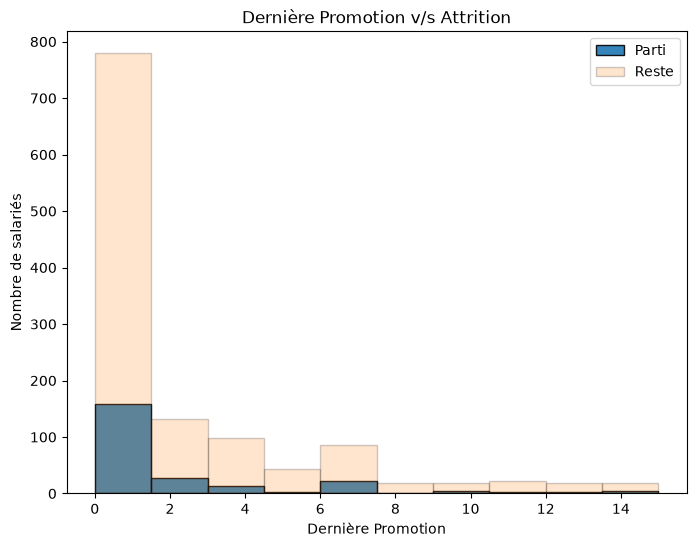

In [65]:
quit_ylp = df[df['Attrition'] == 'Yes']['YearsSinceLastPromotion']
stay_ylp = df[df['Attrition'] == 'No']['YearsSinceLastPromotion']

plot_hist(quit_ylp, stay_ylp, "Dernière Promotion", "Dernière Promotion", "Nombre de salariés")

Nous pouvons observer que les salariés ayant le plus de risque de départs sont ceux dont la promotion est la moins ancienne.

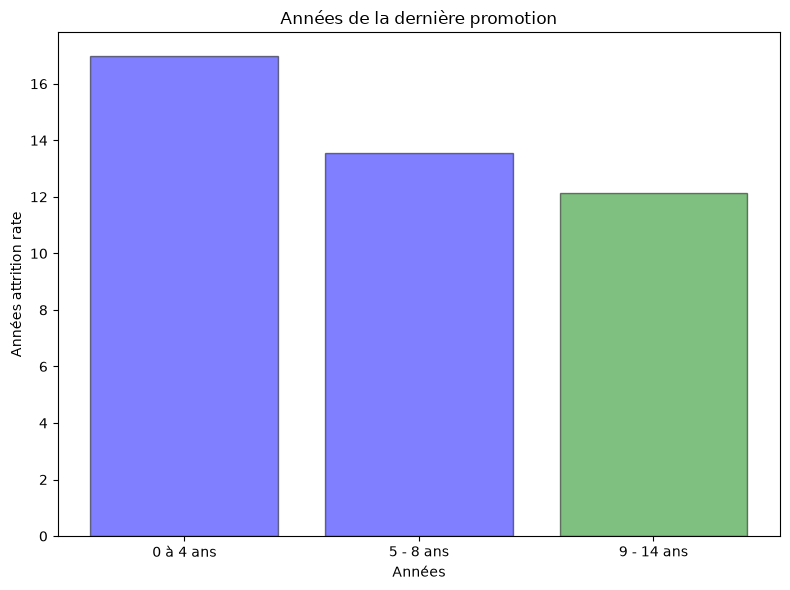

In [66]:
yp = df['YearsSinceLastPromotion_str'].value_counts()
yp_quit = df[df['Attrition'] == 'Yes']['YearsSinceLastPromotion_str'].value_counts()
yp_attritionrate = (yp_quit/yp)*100

plot_analyse(yp_attritionrate, "Années de la dernière promotion", "Années")

Cette représentation démontre bien notre raisonnement précédent, les salariés ayant été augmentés dans les 4 dernières années ont plus de chance de partir que les autres.

Ceci est à étudier au regard de la job satisfaction et du type de promotion mise en place. 

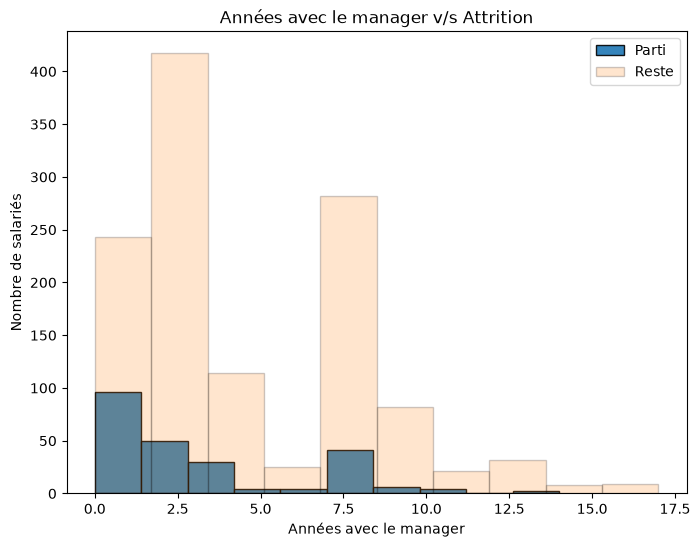

In [67]:
quit_ycm = df[df['Attrition'] == 'Yes']['YearsWithCurrManager']
stay_ycm = df[df['Attrition'] == 'No']['YearsWithCurrManager']

plot_hist(quit_ycm, stay_ycm, "Années avec le manager", "Années avec le manager","Nombre de salariés") #creation du graphique

Nous observons que le temps passé avec le manager, au regard de ce graphique ne semble pas impacter le statut du salarié. Cependant il est important d'analyser en profondeur cette donnée via une autre visualisation.

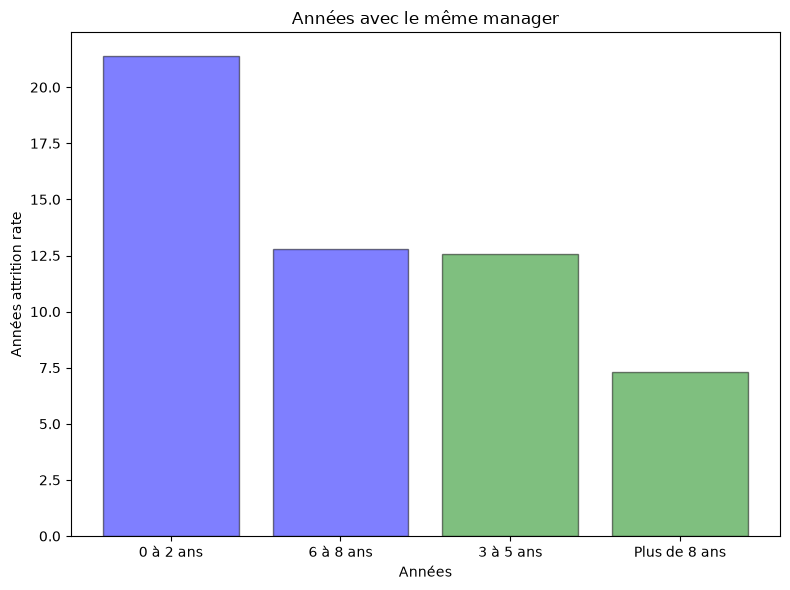

In [68]:
ywc = df['YearsWithCurrManager_str'].value_counts()
ywc_quit = df[df['Attrition'] == 'Yes']['YearsWithCurrManager_str'].value_counts()
ywc_attritionrate = (ywc_quit/ywc)*100

plot_analyse(ywc_attritionrate, "Années avec le même manager", "Années")

Ce graphique démontre que les changements fréquents de managers peuvent être associés à une augmentation de l'attrition au sein de l'entreprise.

**Conclusion de l'analyse**

Cette analyse nous a permis d'appréhender en profondeur les causes hypothétiques de l'attrition au sein de cette entreprise.

Ainsi, nous avons pu identifier 6 valeurs clée telle que : 

* Le taux horaire journalier

* Le département dans lequel travaille le salarié

* La satisfaction au travail et dans l'environnement de travail

* La distance entre le domicile et le lieu de travail

* L'investissement des salariés

* Le salaire

**Recommandations à destination des RH**

Notre analyse nous permet de formuler des recommandations précises afin de limiter l'attrition au sein de l'entreprise : 

* Ajuster les salaires de départs afin de lisser l'impact de l'ancienneté 

* Proposer une aide financière ou en nature pour compenser l'impact de la distance parcourue pour aller aux bureaux, notamment pour les salariés réalisant **au moins 20km**

* Proposer des éléments favorisant l'appréciation de l'environnement de travail 

* Suivre attentivement les paramètres des salariés ayant moins de 5 ans d'ancieneté dans la société, car ce sont eux les plus à risque de partir.


**Limites et perspectives futures**

Cette analyse comporte un certains nombre de limites qu'il est important de mentionner. 
La différence entre les effectifs sortants (yes) et restant (no) est assez importante (~1000) réduisant l'impact de nos calculs et découvertes statistiques. Il serait donc pertinent de réaliser la même analyse sur un échantillon plus large de salariés quittant l'entreprise. 

De plus, les liens statistiques entre certaines valeurs ont complexifié notre analyse, notamment vis à)vis de l'impact du salaire sur les départs. Ainsi, les corrélations et relation intervariables, illustrent des associations et non pas des relations causales.

Pour la suite, il serait pertinent de se concentrer sur des éléments plus profonds tel que l'impact du manager sur la satisfaction et l'engagement du salarié, afin de potentiellement détecter des situations jugées toxiques.

De plus, la modélisation prédictive de l'attrition est l'étape suivante à cette analyse, afin non pas d'obtenir des recommandations, mais un vrai modèle permettant d'identifier le salarié à risque et de réduire l'attrition
